In [14]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download('nelgiriyewithana/emotions')
df = pd.read_csv(path + '/text.csv')

print(df.shape)
print('Path to dataset files:', path)

(416809, 3)
Path to dataset files: /home/jens/.cache/kagglehub/datasets/nelgiriyewithana/emotions/versions/1


In [15]:
df.describe()

,Unnamed: 0,label
count,416809.000000,416809.000000
mean,208404.000000,1.554271
std,120322.538513,1.490453
min,0.000000,0.000000
25%,104202.000000,0.000000
50%,208404.000000,1.000000
75%,312606.000000,3.000000
max,416808.000000,5.000000


In [16]:
df.sample(5, random_state=42)

,Unnamed: 0,text,label
36130,36130,id say maybe made them feel foolish but that w...,0
138065,138065,i joined the lds church i admit to feeling som...,0
146440,146440,i must admit i didnt feel like hugging him not...,3
103337,103337,i hate that i can still feel if any nerve is d...,0
315528,315528,im actually feeling a little smug,1


In [17]:
EMOTION_MAP = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

df['emotion_name'] = df['label'].map(EMOTION_MAP)

print('Label counts:')
print(df['emotion_name'].value_counts())
print()
print('Unique emotions:', df['emotion_name'].unique())

Label counts:
emotion_name
joy         141067
sadness     121187
anger        57317
fear         47712
love         34554
surprise     14972
Name: count, dtype: int64

Unique emotions: <StringArray>
['fear', 'sadness', 'love', 'joy', 'surprise', 'anger']
Length: 6, dtype: str


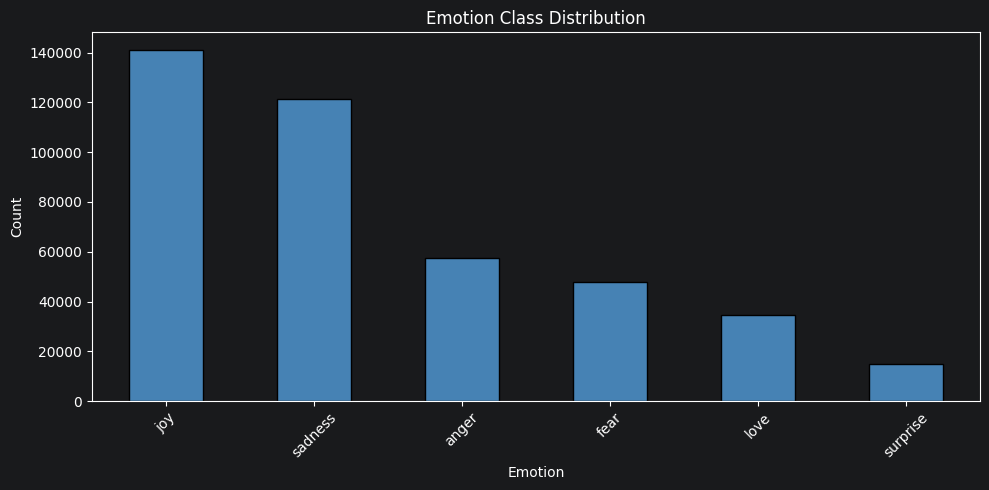

In [18]:
import matplotlib.pyplot as plt

df['emotion_name'].value_counts().plot(kind='bar', figsize=(10, 5), color='steelblue', edgecolor='black')
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
print(df.shape)
clean_df = df[['text', 'label', 'emotion_name']].copy()
clean_df.dropna(inplace=True)
clean_df.drop_duplicates(inplace=True)
print(clean_df.shape)
clean_df.head(5)

(416809, 4)
(416123, 3)


,text,label,emotion_name
0,i just feel really helpless and heavy hearted,4,fear
1,ive enjoyed being able to slouch about relax a...,0,sadness
2,i gave up my internship with the dmrg and am f...,4,fear
3,i dont know i feel so lost,0,sadness
4,i am a kindergarten teacher and i am thoroughl...,4,fear


In [20]:
clean_df['text'] = clean_df['text'].str.strip()
clean_df.head(5)

,text,label,emotion_name
0,i just feel really helpless and heavy hearted,4,fear
1,ive enjoyed being able to slouch about relax a...,0,sadness
2,i gave up my internship with the dmrg and am f...,4,fear
3,i dont know i feel so lost,0,sadness
4,i am a kindergarten teacher and i am thoroughl...,4,fear


In [21]:
from sklearn.model_selection import train_test_split

x = clean_df['text'].values
y = clean_df['label'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print('Train size:', len(x_train))
print('Test size: ', len(x_test))

Train size: 332898
Test size:  83225


In [22]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [23]:
MODEL_NAME    = 'bert-base-uncased'
MAX_LEN       = 64
BATCH_SIZE    = 64
EPOCHS        = 3
LEARNING_RATE = 2e-5
NUM_CLASSES   = 6

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded.')
print('Number of classes:', NUM_CLASSES)

Tokenizer loaded.
Number of classes: 6


In [24]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = EmotionDataset(x_train, y_train, tokenizer, MAX_LEN)
test_dataset  = EmotionDataset(x_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print('Train batches:', len(train_loader))
print('Test batches: ', len(test_loader))

Train batches: 5202
Test batches:  1301


In [25]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model = model.to(device)
print('Model loaded and moved to', device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 22817.56it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

Model loaded and moved to cuda


In [26]:
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print('Total training steps:', total_steps)

Total training steps: 15606


In [ ]:
import time

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    start = time.time()

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        if (step + 1) % 100 == 0:
            elapsed = time.time() - start
            print(f'  Epoch {epoch+1} | Step {step+1}/{len(train_loader)} | '
                  f'Loss: {total_loss / (step+1):.4f} | Elapsed: {elapsed:.1f}s')

    avg_loss = total_loss / len(train_loader)
    print(f'\nEpoch {epoch+1} complete — Avg Loss: {avg_loss:.4f}\n')

  Epoch 1 | Step 100/5202 | Loss: 1.7389 | Elapsed: 36.0s
  Epoch 1 | Step 200/5202 | Loss: 1.6793 | Elapsed: 71.4s
  Epoch 1 | Step 300/5202 | Loss: 1.5692 | Elapsed: 106.4s
  Epoch 1 | Step 400/5202 | Loss: 1.4468 | Elapsed: 141.2s
  Epoch 1 | Step 500/5202 | Loss: 1.3092 | Elapsed: 176.0s
  Epoch 1 | Step 600/5202 | Loss: 1.1696 | Elapsed: 210.8s
  Epoch 1 | Step 700/5202 | Loss: 1.0502 | Elapsed: 245.7s
  Epoch 1 | Step 800/5202 | Loss: 0.9503 | Elapsed: 280.5s
  Epoch 1 | Step 900/5202 | Loss: 0.8673 | Elapsed: 315.3s
  Epoch 1 | Step 1000/5202 | Loss: 0.7999 | Elapsed: 350.2s
  Epoch 1 | Step 1100/5202 | Loss: 0.7431 | Elapsed: 385.0s
  Epoch 1 | Step 1200/5202 | Loss: 0.6939 | Elapsed: 419.8s
  Epoch 1 | Step 1300/5202 | Loss: 0.6527 | Elapsed: 454.6s
  Epoch 1 | Step 1400/5202 | Loss: 0.6166 | Elapsed: 489.4s
  Epoch 1 | Step 1500/5202 | Loss: 0.5845 | Elapsed: 524.2s
  Epoch 1 | Step 1600/5202 | Loss: 0.5558 | Elapsed: 559.0s
  Epoch 1 | Step 1700/5202 | Loss: 0.5302 | Elapsed

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_pred      = all_preds
y_test_eval = all_labels

accuracy  = accuracy_score(y_test_eval, y_pred)
precision = precision_score(y_test_eval, y_pred, average='weighted')
recall    = recall_score(y_test_eval, y_pred, average='weighted')
f1        = f1_score(y_test_eval, y_pred, average='weighted')

print(f'Accuracy:  {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall:    {recall * 100:.2f}%')
print(f'F1-score:  {f1 * 100:.2f}%')

emotion_names = [EMOTION_MAP[i] for i in range(NUM_CLASSES)]
print('\nClassification Report:\n',
      classification_report(y_test_eval, y_pred, target_names=emotion_names))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_eval, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)
plt.title('Confusion Matrix — BERT Emotion Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
model_save_path = f'emotion_bert_model_acc_{accuracy * 100:.2f}%'
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)
print('BERT model saved to:', model_save_path)

In [ ]:
# Inference helper — predict emotion from raw text

def predict_emotion(text, model, tokenizer, max_len=64):
    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        pred   = torch.argmax(logits, dim=1).item()

    return EMOTION_MAP[pred]


samples = [
    'I am so happy today, everything is going great!',
    'I feel absolutely devastated and cannot stop crying.',
    'This makes me so angry, I cannot believe it happened.',
    'I am really scared about what might happen next.',
    'Wow, I never expected that to happen!',
    'I love spending time with the people I care about.',
]

print('Emotion Predictions:')
print('--------------------------------------')
for s in samples:
    print(f'Text:    {s}')
    print(f'Emotion: {predict_emotion(s, model, tokenizer)}')
    print()